<a href="https://colab.research.google.com/github/sensayan288-arch/Diabetes---Predictor/blob/main/Netflix-Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('netflix_titles.csv')
df.head()
df.tail()
df.shape
df.isnull().sum()
df.dtypes
df['rating']=df['rating'].fillna(df['rating'].mode()[0])

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2624
cast,825
country,830
date_added,0
release_year,0
rating,0
duration,3


In [ ]:
df = df.dropna(subset=['date_added'])

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2624
cast,825
country,830
date_added,0
release_year,0
rating,0
duration,3


In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


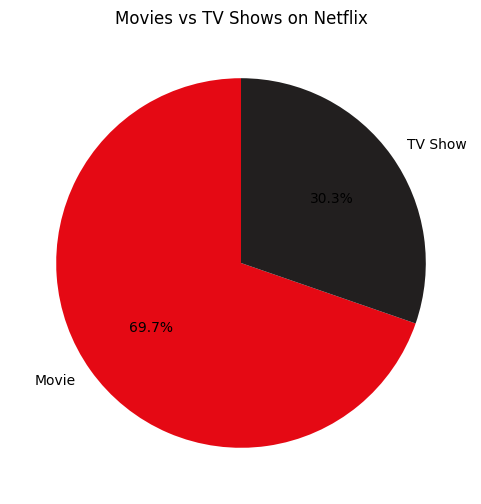

In [ ]:
counts = df['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['#E50914', '#221f1f'])
plt.title('Movies vs TV Shows on Netflix')
plt.show()

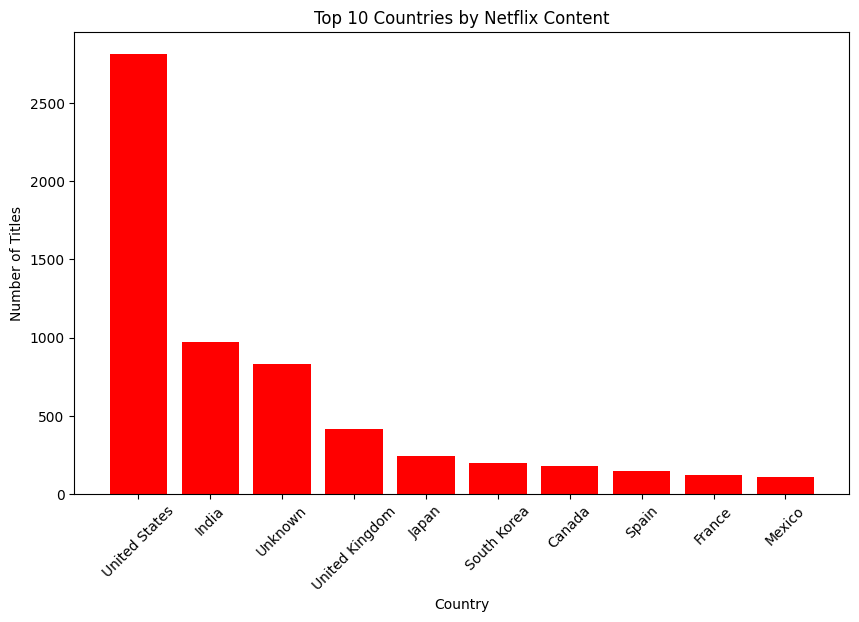

In [ ]:
counts = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(counts.index, counts.values, color='red')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.title('Top 10 Countries by Netflix Content')
plt.xticks(rotation=45)
plt.show()

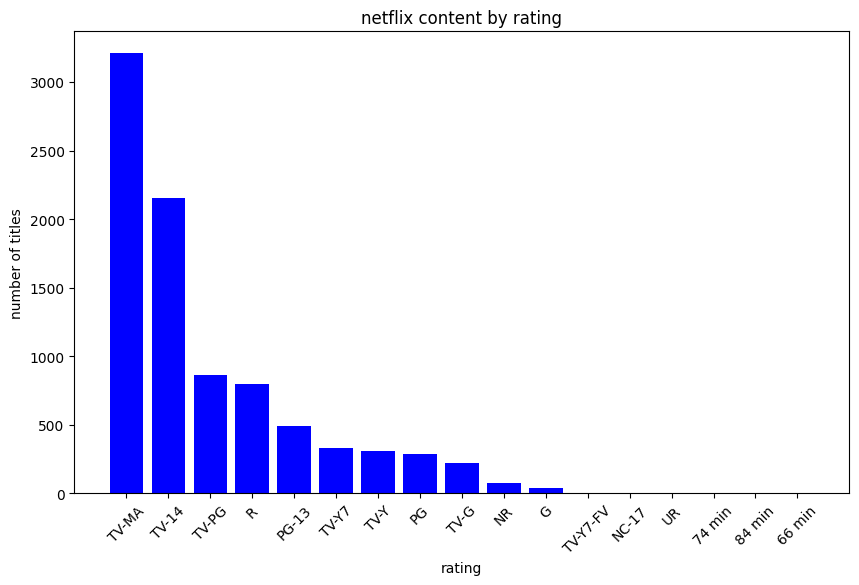

In [ ]:
counts = df['rating'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(counts.index, counts.values,color='blue')
plt.xlabel('rating')
plt.ylabel('number of titles')
plt.title('netflix content by rating')
plt.xticks(rotation=45)
plt.show()

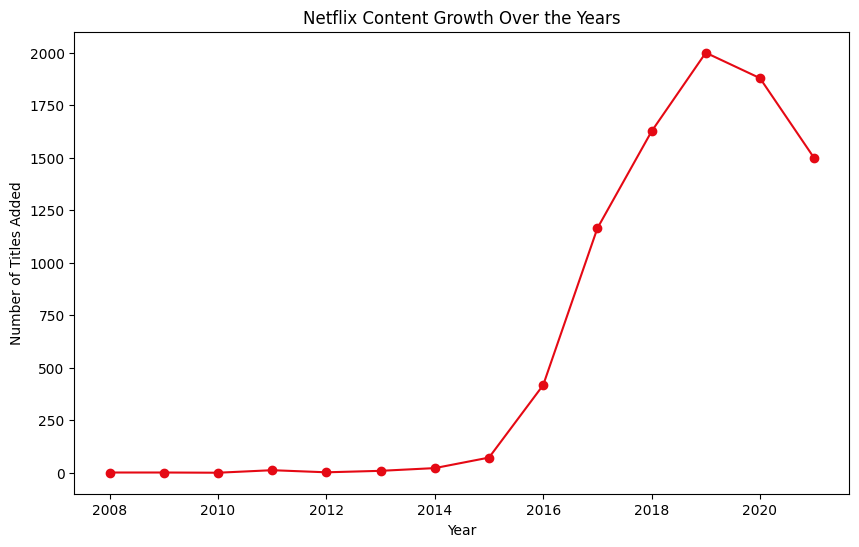

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

yearly_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o', color='#E50914')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.title('Netflix Content Growth Over the Years')
plt.show()

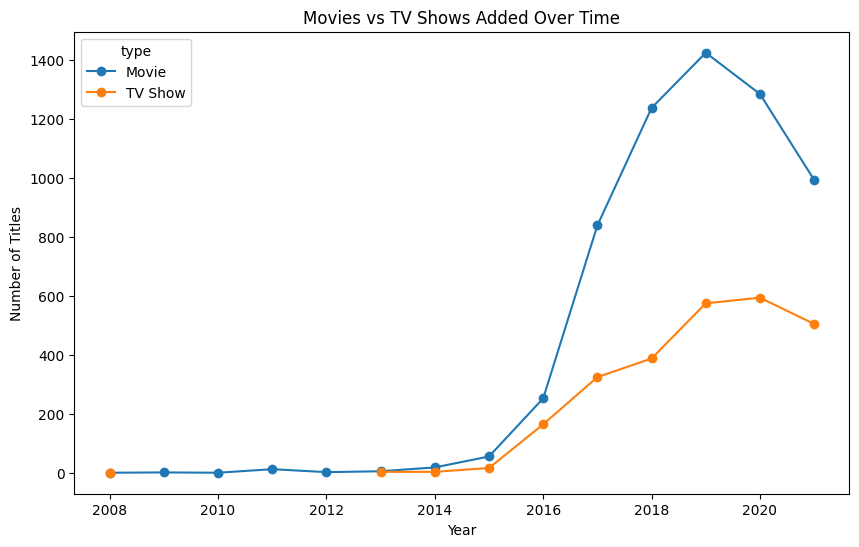

In [ ]:
trend = df.groupby(['year_added', 'type']).size().unstack()

plt.figure(figsize=(10,6))
trend.plot(marker='o', ax=plt.gca())
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.title('Movies vs TV Shows Added Over Time')
plt.show()